In [9]:
from ultralytics import YOLO
import torch
import os

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
model = YOLO(f'yolov8s.pt')

Using device: cuda


In [ ]:
data_yaml = "Helmet detection.v1i.yolov9/data.yaml"
model = YOLO(f'Models/helmet_model_yolov8_initial1.pt')
model.train(
        data=data_yaml,
        epochs=20,
        imgsz=640,
        batch=8 ,  # Adjust batch size based on model size
        device=device,
        optimizer='adam',
        lr0=0.001,  # Initial learning rate
        name=f'helmet_app2_yolov8',  # Experiment name
        patience=100,  # Early stopping patience
        save=True,
        save_period=5
)

New https://pypi.org/project/ultralytics/8.3.99 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.95 🚀 Python-3.10.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 970, 4030MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=license_data/data.yaml, epochs=20, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=5, cache=False, device=cuda, workers=8, project=None, name=license_plate_yolov8, exist_ok=False, pretrained=True, optimizer=adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, sh

train: Scanning /home/STUDENTS/MSC/DS/22PD/22pd18/License-Plate---Helmet-Detection/license_data/train/labels... 7057 images, 5 backgrounds, 0 corrupt: 100%|██████████| 70


train: New cache created: /home/STUDENTS/MSC/DS/22PD/22pd18/License-Plate---Helmet-Detection/license_data/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /home/STUDENTS/MSC/DS/22PD/22pd18/License-Plate---Helmet-Detection/license_data/valid/labels... 2048 images, 3 backgrounds, 0 corrupt: 100%|██████████| 2048


val: New cache created: /home/STUDENTS/MSC/DS/22PD/22pd18/License-Plate---Helmet-Detection/license_data/valid/labels.cache
Plotting labels to runs/detect/license_plate_yolov8/labels.jpg... 
optimizer: Adam(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/license_plate_yolov8
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/20      2.29G      1.796      5.547      1.588         12        640:   2%|▏         | 14/883 [00:21<58:48,  4.06s/it]

In [4]:
model.save("Models/helemet_model_yolov8_initial2.pt")
print("Model saved as 'helemet_model_yolov8_initial2.pt'")

Model saved as 'helmet_model_yolov8_initial2.pt'


In [5]:
def evaluate_model(model, dataset_yaml):
    metrics = model.val(
        data=dataset_yaml,
        split='test',  # or 'test'
        imgsz=640,
        conf=0.25,  # Confidence threshold
        iou=0.45,  # IoU threshold
        device='0' if torch.cuda.is_available() else 'cpu'
    )
    
    # Print key metrics
    print("\nEvaluation Results:")
    print(f"Precision: {metrics.box.map:.3f}")  # mAP@0.5
    print(f"Recall: {metrics.box.map50:.3f}")  # mAP@0.5:0.95
    print(f"mAP@0.5:0.95: {metrics.box.map75:.3f}")
    
    return metrics

# Run evaluation
val_metrics = evaluate_model(model, data_yaml)

Ultralytics 8.3.95 🚀 Python-3.10.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 970, 4030MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /home/STUDENTS/MSC/DS/22PD/22pd18/License-Plate---Helmet-Detection/Helmet detection.v1i.yolov9/test/labels... 254 images, 0 backgrounds, 0 corrupt: 100%|███

val: New cache created: /home/STUDENTS/MSC/DS/22PD/22pd18/License-Plate---Helmet-Detection/Helmet detection.v1i.yolov9/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:06<00:00,  4.91it/s]


                   all        254        480      0.838      0.719       0.82      0.486
           with helmet        147        266      0.832      0.725      0.831      0.519
        without helmet        143        214      0.845      0.713      0.809      0.453
Speed: 1.4ms preprocess, 14.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/helmet_app2_yolov8112

Evaluation Results:
Precision: 0.486
Recall: 0.820
mAP@0.5:0.95: 0.530



image 1/1 /home/STUDENTS/MSC/DS/22PD/22pd18/Final_DL_package/yolo_twowheeler_dataset/test/images/image_307_jpg.rf.05e4191aa56c2650e24084b3ce5d580d.jpg: 640x640 2 with helmets, 145.8ms
Speed: 5.2ms preprocess, 145.8ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict3


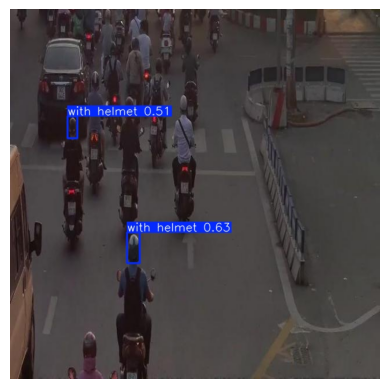

In [6]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your trained model
model = YOLO("models/helmet_model_yolov8_initial2.pt")

# Run inference on a single image
image_path = "yolo_twowheeler_dataset/test/images/image_307_jpg.rf.05e4191aa56c2650e24084b3ce5d580d.jpg"
results = model.predict(source=image_path, conf=0.5, save=True)  # saves to runs/detect/predict

# Display with matplotlib (better for notebooks)
# Save and reload the image
output_path = "result_model22.jpg"
cv2.imwrite(output_path, results[0].plot())

# Display in notebook
plt.imshow(plt.imread(output_path))
plt.axis('off')
plt.show()